<a href="https://colab.research.google.com/github/MoamenTalaat04/Connect-Hub/blob/main/assignment_3%20/ML_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from itertools import combinations



#Preparing Data


In [ ]:
cols = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

data= pd.read_csv("/content/adult.data", names=cols,sep=",", engine="python", na_values="?")

cat_features = ["workclass", "education", "marital-status",
                "occupation", "relationship", "race", "sex", "native-country"]

df= data[cat_features+["income"]].copy() #only Discrete data

df.fillna("Unknown", inplace=True)

encoders = {} # Unique Integer for each category
for col in cat_features + ["income"]:
    encoders[col] = {cat: idx for idx, cat in enumerate(df[col].unique())}
    df[col] = df[col].map(encoders[col])


X = df[cat_features]
y = df["income"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, stratify=y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.5)



#Naive Bayes Model

In [ ]:
class NaiveBayes :
  def __init__(self , alpha =1):
    self.alpha = alpha
    self.class_priors = {} #Priors -> P(>50),P(<50)
    self.feature_likelihoods = {} #Likelihoods -> P(feature | Class )
    self.num_classes = 0
    self.cat_values = {} # counting number of unique values in column

  def fit(self , X ,Y ):
    num_samples , num_features = X.shape
    self.classes ,counts=np.unique (Y , return_counts=True) # Getting the number of Unique Outputs
    num_classes=len(self.classes)

    # Getting the priors as C will be = 0 in one of the output and 1 for the other then i will count for each
    self.class_priors = {
      c:(counts[i]+self.alpha)/(num_samples+self.alpha*num_classes) for i ,c in enumerate(self.classes)
      }

    #Initialize the Likelihoods to be used later
    self.feature_likelihoods={
        c:[defaultdict(float) for _ in range(num_features)] for c in self.classes
    }

    #Count number of unique features to be used in Calculation of Likelihoods
    self.cat_values = {j: len(np.unique(X[:, j])) for j in range(num_features)}

    # this calculates the Likelihood of each class
    for c in self.classes:
      X_c = X[Y == c]  # all rows belonging to class c
      for j in range(num_features):  # loop over each feature
        values, value_counts = np.unique(X_c[:, j], return_counts=True)
        for v, cnt in zip(values, value_counts):
            self.feature_likelihoods[c][j][v] = (cnt + self.alpha) / \
                (len(X_c) + self.alpha * self.cat_values[j])

  def predict(self ,X ):
    preds=[]
    for x in X :
      class_prop={}
      for c in self.classes :
        prob = np.log(self.class_priors[c]) # log for stability
        for j ,val in enumerate(x):
          prob+=np.log(self.feature_likelihoods[c][j].get(val, self.alpha / (self.alpha * self.cat_values[j])))
        class_prop[c]=prob
      preds.append(max(class_prop , key=class_prop.get))
    return preds



  def predict_proba(self, X):
        """Return probability distribution over classes for each sample."""
        probs = []
        for x in X:
            class_probs = {}
            for c in self.classes:
                log_prob = np.log(self.class_priors[c])
                for j, val in enumerate(x):
                    log_prob += np.log(self.feature_likelihoods[c][j].get(val,
                                self.alpha / (self.alpha * self.cat_values[j])))
                class_probs[c] = np.exp(log_prob)
            # Normalize probabilities
            total = sum(class_probs.values())
            probs.append([class_probs[c] / total for c in self.classes])
        return np.array(probs)

#Tuninig Paramaters and making Subsets of Data

In [ ]:


# --- Parameters ---
subset_sizes = [3, 5, len(cat_features)]  # test subsets of 3, 5, and all categorical features
alpha_values = [0.1, 0.5, 1.0, 2.0, 5.0]  # Laplace smoothing values

# --- Results container ---
results = []

# --- Loop through feature subsets and alpha values ---
for size in subset_sizes:
    for subset in combinations(cat_features, size):
        subset = list(subset)

        # Select columns for training/validation
        X_train_fs = X_train[subset].values
        y_train_fs = y_train.values
        X_val_fs = X_val[subset].values
        y_val_fs = y_val.values

        for alpha in alpha_values:
            nb = NaiveBayes(alpha=alpha)
            nb.fit(X_train_fs, y_train_fs)
            preds = nb.predict(X_val_fs)

            # Calculate metrics
            acc = accuracy_score(y_val_fs, preds)
            f1 = f1_score(y_val_fs, preds, pos_label=1)

            results.append({
                "Features Used": subset,
                "Num Features": len(subset),
                "Alpha": alpha,
                "Validation Accuracy": acc,
                "Validation F1 (>50K)": f1
            })

# --- Convert to DataFrame and sort results ---

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="Validation F1 (>50K)", ascending=False)
print(df_results.head(10))
print(100*"-")
df_results=df_results.sort_values(by="Validation Accuracy", ascending=False)
print(df_results.head(10))



                                         Features Used  Num Features  Alpha  \
283  [workclass, education, marital-status, occupat...             5    2.0   
282  [workclass, education, marital-status, occupat...             5    1.0   
284  [workclass, education, marital-status, occupat...             5    5.0   
281  [workclass, education, marital-status, occupat...             5    0.5   
280  [workclass, education, marital-status, occupat...             5    0.1   
457  [education, marital-status, occupation, relati...             5    1.0   
455  [education, marital-status, occupation, relati...             5    0.1   
456  [education, marital-status, occupation, relati...             5    0.5   
459  [education, marital-status, occupation, relati...             5    5.0   
458  [education, marital-status, occupation, relati...             5    2.0   

     Validation Accuracy  Validation F1 (>50K)  
283             0.800369              0.637142  
282             0.800369        

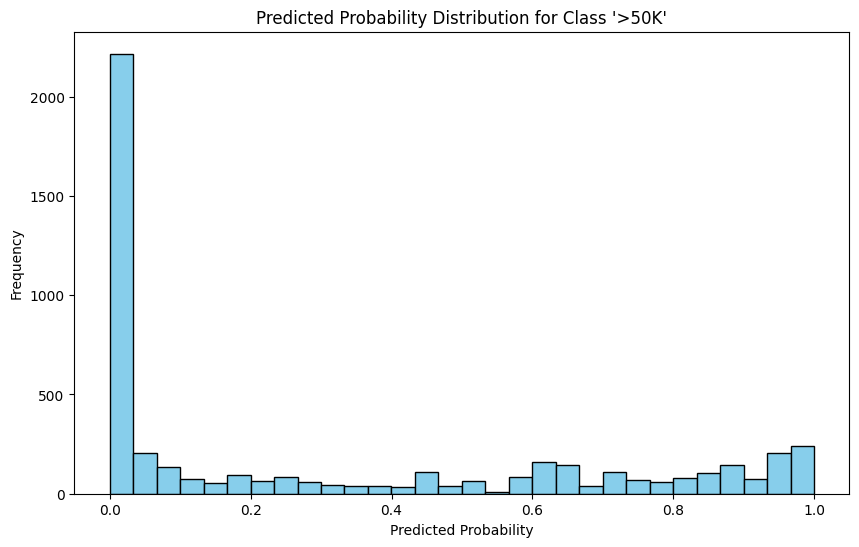

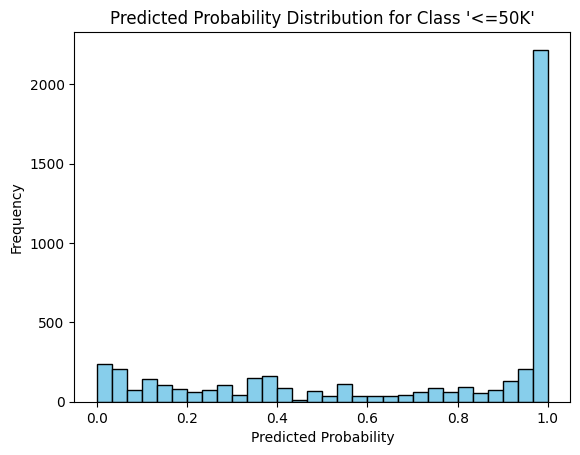

In [ ]:
nb= NaiveBayes(alpha=1.0)
nb.fit(X_train.values , y_train.values)
probs = nb.predict_proba(X_val.values)

plt.figure(figsize=(10, 6))
plt.hist(probs[:, 1], bins=30, color='skyblue', edgecolor='black')
plt.title("Predicted Probability Distribution for Class '>50K'")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()
plt.hist(probs[:, 0], bins=30, color='skyblue', edgecolor='black')
plt.title("Predicted Probability Distribution for Class '<=50K'")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()

#🎯 Effect: Overconfidence

Predictions for many samples become very extreme (near 0 or 1), even if the evidence isn’t that strong.

That’s why your probability histogram has spikes at 0.0 and 1.0.

The model’s class predictions (highest probability) can still be correct, but the actual probability numbers are poorly calibrated.

In [ ]:

nb_sklearn = MultinomialNB(alpha=1.0)
nb_sklearn.fit(X_train, y_train)
sk_preds = nb_sklearn.predict(X_val)

print("\nSklearn MultinomialNB:")
print("Accuracy :", accuracy_score(y_val, sk_preds))
print("Precision:", precision_score(y_val, sk_preds))
print("Recall   :", recall_score(y_val, sk_preds))
print("F1 Score :", f1_score(y_val, sk_preds))



Sklearn MultinomialNB:
Accuracy : 0.7604422604422605
Precision: 0.5182926829268293
Recall   : 0.07227891156462585
F1 Score : 0.12686567164179105


# 🔑 Why Your Model Is More Accurate Here:

Your dataset is categorical (workclass, education, marital-status, etc.).

MultinomialNB was designed for text classification (count vectors).

The written code:

Treats each feature as a discrete categorical variable.

Calculates exact
𝑃
(
category
∣
class
)
P(category∣class) for each value.

MultinomialNB:

Sees integers as numeric counts, not category IDs.

This mismatch makes its probabilities less precise here.